In [1]:
!pip install pandas matplotlib seaborn openpyxl

Original Dataset
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Dataset Shape Before Cleaning: (249, 7)

Dataset Shape After Cleaning: (243, 7)



     AUTOMATED DATA REPORT


----- Automated Data Report -----

Missing Values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  243 non-null    float64
 1   tip         243 non-null    float64
 2   sex         243 non-null    object 
 3   smoker      243 non-null    object 
 4 

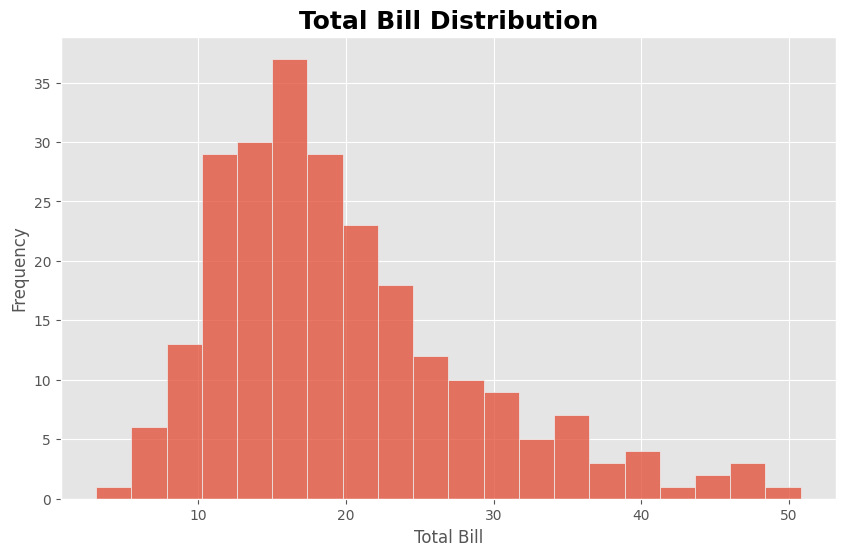



       Average Tips by Day



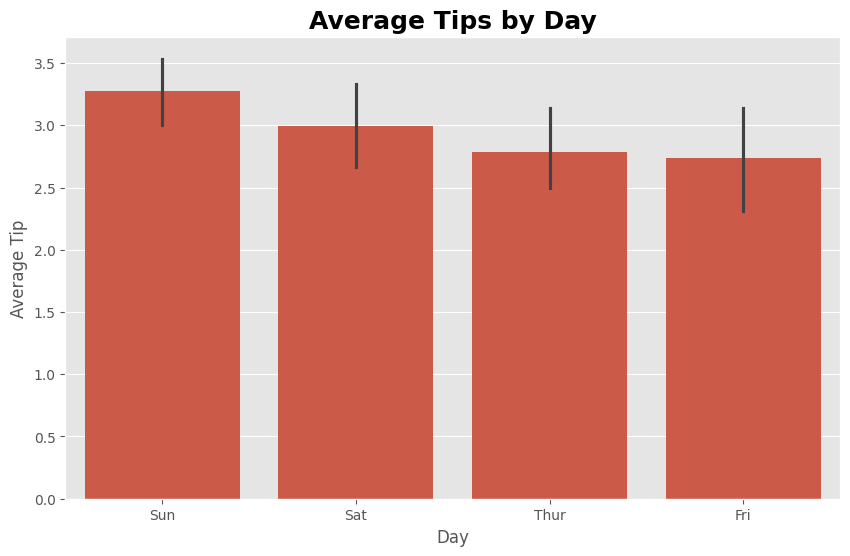


Cleaned dataset exported successfully!


In [4]:
# =========================================
# Data Cleaning & Reporting Automation
# Developed by Prabhu Raj
# =========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")

# Display Original Data
print("Original Dataset")
print(df.head())

# -----------------------------------------
# Create Artificial Missing Values
# -----------------------------------------

df.loc[5, 'total_bill'] = None
df.loc[10, 'tip'] = None

# Duplicate Data
df = pd.concat([df, df.iloc[0:5]], ignore_index=True)

print("\nDataset Shape Before Cleaning:", df.shape)

# -----------------------------------------
# Data Cleaning
# -----------------------------------------

# Handle Missing Values
df['total_bill'] = df['total_bill'].fillna(df['total_bill'].mean())

df['tip'] = df['tip'].fillna(df['tip'].mean())

# Remove Duplicates
df.drop_duplicates(inplace=True)

print("\nDataset Shape After Cleaning:", df.shape)
print("\n\n")
print("===================================")
print("     AUTOMATED DATA REPORT")
print("===================================\n")

# -----------------------------------------
# Automated Report
# -----------------------------------------

print("\n----- Automated Data Report -----")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# -----------------------------------------
# Visualization
# -----------------------------------------

plt.style.use('ggplot')

# Total Bill Distribution
print("\n")
print("===================================")
print("     Total Bill Distribution")
print("===================================\n")

# Total Bill Distribution
plt.figure(figsize=(10,6))

sns.histplot(df['total_bill'], bins=20)

plt.title("Total Bill Distribution",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Total Bill")
plt.ylabel("Frequency")

plt.show()

# Tips by Day
print("\n")
print("===================================")
print("       Average Tips by Day")
print("===================================\n")

# Tips by Day
plt.figure(figsize=(10,6))

sns.barplot(x='day', y='tip', data=df)

plt.title("Average Tips by Day",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Day")
plt.ylabel("Average Tip")

plt.show()

# -----------------------------------------
# Export Cleaned Data
# -----------------------------------------

df.to_csv("cleaned_tips_data.csv", index=False)

print("\nCleaned dataset exported successfully!")